# 02b — Data extraction (π⁺): from showers to a handful of numbers per event

**This is the pion (π⁺) sibling of [`02_data_extraction.ipynb`](02_data_extraction.ipynb).**
It runs the *same* extraction pipeline and produces the *same* four readouts, but
on the **π⁺ dataset** instead of photons. Compare your plots here with the photon
version side by side to see **electromagnetic vs hadronic** behaviour.

### Why the contrast matters

The DECAL is an **electromagnetic** Si–W calorimeter: ~25 X₀ deep, but only a
*fraction* of a nuclear interaction length λ_I. A photon dumps a clean, compact
EM shower in the first ~half of the stack. A high-energy **π⁺ usually does not**.
Two regimes dominate, and the dataset is a mixture of both:

1. **MIP punch-through (the common case).** The π⁺ traverses the silicon as a
   minimum-ionizing particle, leaving a thin, near-straight track of ~MIP-sized
   hits — *very few* pixels, *low* deposited energy. (A 50 GeV π⁺ left ~35 silicon
   crossings in this geometry, versus ~3000 pixels for a 50 GeV photon's EM
   shower.)
2. **Early hadronic interaction.** A nuclear interaction in the tungsten makes a
   messy, wide, irregular shower with a large EM sub-component from π⁰ → 2γ.
   Those π⁰ sub-showers *locally* look just like the photon showers from the
   sibling notebook — but they sit on top of charged hadronic debris and start at
   a random, often late depth.

**What to expect (vs the photon sibling):**

| | photon (02) | π⁺ (02b) |
|---|---|---|
| hits per event | many, clean | **far fewer on average, huge event-to-event spread** |
| sampling fraction | tight ~constant | **lower and highly variable** |
| longitudinal profile | smooth EM peak | **flat/sparse (punch-through) or deep/late (interacting)** |
| transverse pattern | compact EM blob | **often a narrow MIP line** |
| readout ↔ E_true | tight band | **loose, wide band at fixed E** |

Everything downstream is identical to the photon notebook — that is the point.
The output is written to a **pion-specific** file,
`decal_extracted_data_piplus.npz`, so it never clobbers the photon npz and
[`03b_ml_training_and_eval_pions.ipynb`](03b_ml_training_and_eval_pions.ipynb)
can read it.

---


## Overview: from showers to a handful of numbers per event

Each simulated event is a single π⁺ traversing the calorimeter — but unlike a
photon it is *not* always a full electromagnetic shower. A punch-through π⁺ leaves
only a thin MIP track of a few hits; an interacting π⁺ makes a wide, irregular
spray. Either way we reduce every event to the same **five numbers** (plus a
longitudinal profile) and save them to one small `.npz` for the ML pipeline, so
the photon and pion runs are directly comparable.

The reduction does two physics-motivated things:

1. **Isolates the entry module.** The π⁺ enters one face of the 12-sided barrel.
   A shower (when one develops) isn't fully contained — soft secondaries leak
   across the inner air cavity and strike *other* faces. Those hits are real, but
   they're an artifact of this closed test geometry, not a property of the
   calorimeter technology. A real measurement reads out the module the beam
   enters, so we keep only hits in the **+y 30° wedge** (one of the 12 segments)
   at the silicon radius.
2. **Applies a readout threshold.** A pixel only registers if its deposit clears
   a zero-suppression threshold (~½ MIP), exactly as a real chip would. For a
   punch-through π⁺ almost every surviving hit sits right at the 1-MIP scale.

**Kernel**: `Python (Key4hep)` (CPU; I/O-bound).
**Output**: `$CALOMAPS_HOME/models/decal_extracted_data_piplus.npz`.

## 1. Parameters and detector geometry

The MIP scale (`MIP_ENERGY`) is the Landau most-probable energy deposit of a
minimum-ionizing particle in the silicon sensor. We read the 30 silicon layer
**radii** from the geometry XML so the layer assignment stays correct even inside
the tilted wedge.

In [1]:
import os, glob, xml.etree.ElementTree as ET
import numpy as np, uproot
from concurrent.futures import ProcessPoolExecutor, as_completed

CALOMAPS_HOME = os.environ.get("CALOMAPS_HOME", os.path.expanduser("~/CALOMAPS"))
DATA_BASE     = os.environ.get("CALOMAPS_DATA_BASE", os.path.expanduser("~/CALOMAPS-data"))
DATASET       = "data_spectrum_100um_400GeV_piplus"

CELL_SIZE  = 0.1            # mm — 100 um pixel pitch
MIP_ENERGY = 85e-6          # GeV — Landau MPV for the sensor
THRESHOLD  = 0.5 * MIP_ENERGY   # zero-suppression: a pixel "fires" above 1/2 MIP
NSIDES     = 12                 # dodecagonal barrel
SEG_HALF_DEG = 180.0 / NSIDES   # 15 deg half-wedge (one segment)
RMIN, RMAX = 1264.0, 1403.0     # silicon shell inner/outer radius [mm]

def _pv(v, c):
    if not v: return 0.0
    if v in c: return _pv(c[v], c)
    s = v.replace('*', ' * ').replace('cm', '10').replace('mm', '1')
    try: return float(eval(s, {"__builtins__": None}, {}))
    except Exception:
        try: return float(v)
        except Exception: return 0.0

def layer_radii():
    g = os.path.join(CALOMAPS_HOME, "geometry")
    consts = {x.get("name"): x.get("value")
              for x in ET.parse(os.path.join(g, "SiD_TestBeam.xml")).getroot().findall(".//constant")}
    det = ET.parse(os.path.join(g, "my_custom_ecal.xml")).getroot().find(".//detector[@name='ECalBarrel']")
    cur, planes = _pv(det.find("dimensions").get("rmin"), consts), []
    for layer in det.findall("layer"):
        rep = int(layer.get("repeat", 1)); sl = layer.findall("slice")
        thick = sum(_pv(s.get("thickness"), consts) for s in sl)
        off = sioff = 0.0
        for s in sl:
            t = _pv(s.get("thickness"), consts)
            if s.get("material") == "Silicon": sioff = off + t / 2
            off += t
        for _ in range(rep):
            planes.append(cur + sioff); cur += thick
    return np.array(planes)

RADII = layer_radii()
NUM_LAYERS = len(RADII)
# energy bins for the longitudinal-profile accumulation (25 GeV wide, 0-400)
PROFILE_BINS = [(25 * i, 25 * (i + 1)) for i in range(16)]
print(f"parsed {NUM_LAYERS} silicon layers, r = [{RADII.min():.1f}, {RADII.max():.1f}] mm")

parsed 30 silicon layers, r = [1266.9, 1400.7] mm


## 2. The five numbers we keep per event

| variable | what it is | readout it models |
|---|---|---|
| `all_truth` | true π⁺ energy `√(p²+m²)` (note **m = 0.13957 GeV**, *not* massless) | the label we want to recover |
| `all_visible` | Σ energy of all hits in the segment | **True Analog** (perfect charge sum) |
| `all_mip` | Σ over fired pixels of `round(E_pix/E_MIP)` | **MIP counting** (MIPs-per-pixel) |
| `all_hits` | number of pixels above ½-MIP threshold | **Raw Hits** (pure binary/digital) |
| `all_cluster` | number of 8-connected clusters, summed over layers | **Naive 2D Clustering** |

The same ladder of readout sophistication as the photon notebook — but for π⁺
every rung is **much noisier**. The total signal is split between two
populations: punch-through events deposit almost nothing (a handful of MIP hits),
while interacting events can deposit a large fraction of the energy through their
π⁰ → γγ electromagnetic sub-showers. So at *fixed* true energy the readouts span a
wide range rather than a tight band. The digital readouts (**Hits**,
**Clustering**) still saturate inside the dense EM cores of interacting events,
but that saturation is now subdominant to the **punch-through-vs-interaction**
fluctuation. **Analog** and **MIP** remain the most faithful, yet even they carry
the large hadronic spread.

We *also* accumulate the **longitudinal shower profile** — energy deposited per
silicon layer — averaged in 25 GeV truth-energy bins. For pions this average
mixes flat punch-through tracks with deep, late interactions, so it is lower and
flatter than the photon profile.

## 3. Per-file worker

For each event: keep hits in the +y wedge, assign each to its nearest silicon
layer by radius, compute the five numbers, and accumulate the per-layer energy
profile. Clustering uses an 8-connected flood-fill on the pixel grid (identical
to `DBSCAN(eps=1.5·pitch, min_samples=1)` but O(n)).

In [2]:
def naive_clusters(x, z, layer_idx, e):
    # 8-connected components per layer, summed.
    m = e > THRESHOLD
    if not m.any():
        return 0
    xi = np.round(x[m] / CELL_SIZE).astype(np.int64)
    zi = np.round(z[m] / CELL_SIZE).astype(np.int64)
    li = layer_idx[m]
    total = 0
    for ly in np.unique(li):
        sel = li == ly
        cells_ = set(zip(xi[sel].tolist(), zi[sel].tolist()))
        seen = set()
        for c0 in cells_:
            if c0 in seen:
                continue
            total += 1
            stack = [c0]
            while stack:
                ux, uz = stack.pop()
                if (ux, uz) in seen:
                    continue
                seen.add((ux, uz))
                for dx in (-1, 0, 1):
                    for dz in (-1, 0, 1):
                        v = (ux + dx, uz + dz)
                        if v in cells_ and v not in seen:
                            stack.append(v)
    return total

def process_single_file(filepath):
    br = ["ECalBarrelHits.position.x", "ECalBarrelHits.position.y",
          "ECalBarrelHits.position.z", "ECalBarrelHits.energy",
          "MCParticles.momentum.x", "MCParticles.momentum.y",
          "MCParticles.momentum.z", "MCParticles.mass"]
    T, V, M, H, C = [], [], [], [], []
    p_sum = np.zeros((len(PROFILE_BINS), NUM_LAYERS))   # energy per layer, per E-bin
    p_cnt = np.zeros(len(PROFILE_BINS), dtype=np.int64)
    try:
        with uproot.open(filepath) as f:
            tr = f["events"]
            if tr.num_entries == 0:
                return None
            a = tr.arrays(br)
            truth = np.sqrt(a["MCParticles.momentum.x"][:, 0]**2 +
                            a["MCParticles.momentum.y"][:, 0]**2 +
                            a["MCParticles.momentum.z"][:, 0]**2 +
                            a["MCParticles.mass"][:, 0]**2)
            hx, hy = a["ECalBarrelHits.position.x"], a["ECalBarrelHits.position.y"]
            hz, he = a["ECalBarrelHits.position.z"], a["ECalBarrelHits.energy"]
            for ev in range(len(he)):
                x = np.asarray(hx[ev]); y = np.asarray(hy[ev])
                z = np.asarray(hz[ev]); e = np.asarray(he[ev])
                if len(e) == 0:
                    continue
                r = np.hypot(x, y)
                ang = np.degrees(np.arctan2(x, y))           # angle from +y in x-y plane
                seg = (np.abs(ang) < SEG_HALF_DEG) & (r > RMIN - 4) & (r < RMAX + 14)
                x, z, e, r = x[seg], z[seg], e[seg], r[seg]
                if len(e) == 0:
                    continue
                layer_idx = np.argmin(np.abs(RADII[None, :] - r[:, None]), axis=1)
                thr = e > THRESHOLD
                et = float(truth[ev])
                T.append(et)
                V.append(float(e.sum()))                                       # analog
                M.append(float(np.maximum(1, np.round(e[thr] / MIP_ENERGY)).sum()))  # MIPs/pixel
                H.append(int(thr.sum()))                                        # binary hits
                C.append(naive_clusters(x, z, layer_idx, e))                    # clusters
                # longitudinal profile: total energy per layer, into its E-bin
                le = np.bincount(layer_idx, weights=e, minlength=NUM_LAYERS)[:NUM_LAYERS]
                for b, (lo, hi) in enumerate(PROFILE_BINS):
                    if lo <= et < hi:
                        p_sum[b] += le; p_cnt[b] += 1
                        break
    except Exception as ex:
        print(f"  failed {os.path.basename(filepath)}: {ex}")
        return None
    return T, V, M, H, C, p_sum, p_cnt

## 4. Run the extraction in parallel and save

Forks a process pool over the π⁺ files (the printout below shows how many were
found). With the grid clustering this is I/O-bound and finishes in well under a
couple of minutes — and pion events, being sparser on average, are if anything
faster to process than photon showers.

In [3]:
file_list = sorted(glob.glob(os.path.join(DATA_BASE, DATASET, "sim_piplus_part*.root")))
print(f"Found {len(file_list)} files. Extracting...")

all_truth, all_visible, all_mip, all_hits, all_cluster = [], [], [], [], []
prof_sum = np.zeros((len(PROFILE_BINS), NUM_LAYERS))
prof_cnt = np.zeros(len(PROFILE_BINS), dtype=np.int64)
with ProcessPoolExecutor(max_workers=min(32, os.cpu_count() or 8)) as ex:
    futures = {ex.submit(process_single_file, f): f for f in file_list}
    for n, fut in enumerate(as_completed(futures), 1):
        r = fut.result()
        if r:
            all_truth += r[0]; all_visible += r[1]; all_mip += r[2]
            all_hits += r[3]; all_cluster += r[4]
            prof_sum += r[5]; prof_cnt += r[6]
        if n % 100 == 0:
            print(f"  {n}/{len(file_list)}")

all_truth   = np.array(all_truth)
all_visible = np.array(all_visible, dtype=np.float32)
all_mip     = np.array(all_mip, dtype=np.float32)
all_hits    = np.array(all_hits, dtype=np.int64)
all_cluster = np.array(all_cluster, dtype=np.int64)

out_dir = os.path.join(CALOMAPS_HOME, "models"); os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "decal_extracted_data_piplus.npz")
np.savez_compressed(out_path, all_truth=all_truth, all_visible=all_visible,
                    all_mip=all_mip, all_hits=all_hits, all_cluster=all_cluster,
                    profile_sum=prof_sum, profile_counts=prof_cnt,
                    layer_radii=RADII, profile_bins=np.array(PROFILE_BINS))
print(f"\nExtracted {len(all_truth)} events -> {out_path} ({os.path.getsize(out_path)/1024:.0f} KB)")

Found 100 files. Extracting...


  100/100

Extracted 2000 events -> /nashome/m/murtazas/CALOMAPS/models/decal_extracted_data_piplus.npz (41 KB)


## 5. The raw readout distributions

Plot each readout against true energy. The dashed line is a straight fit to the
**low-energy** region (< 50 GeV), extrapolated across the full range. For photons
this line cleanly exposes the high-energy *digital breakdown*; **for π⁺ the
dominant story is different** — the cloud is **wide at every energy**:

- **Two populations, not one band.** A low-lying locus of **punch-through** events
  (few hits, little deposited energy, roughly energy-independent) sits beneath a
  higher, broad spread of **interacting** events. The vertical scatter is no
  longer "just resolution" — it is the physical mix of two shower regimes.
- **Analog / MIP** still track energy on average, but with large hadronic
  fluctuations; the band is far thicker than the photon's.
- **Raw Hits / Clustering** also saturate inside the dense EM cores of interacting
  events (one 100 µm pixel hit by several particles still counts once), but for
  pions that saturation is secondary to the punch-through-vs-interaction split.

Compare directly with the photon sibling: there the four panels are tight bands
that bend over at high E; here they are **loose, two-lobed clouds**. The large
spread at fixed energy is exactly what makes pion energy reconstruction harder —
it is what the quantile ensembles in
[`03b_ml_training_and_eval_pions.ipynb`](03b_ml_training_and_eval_pions.ipynb)
must learn to model.

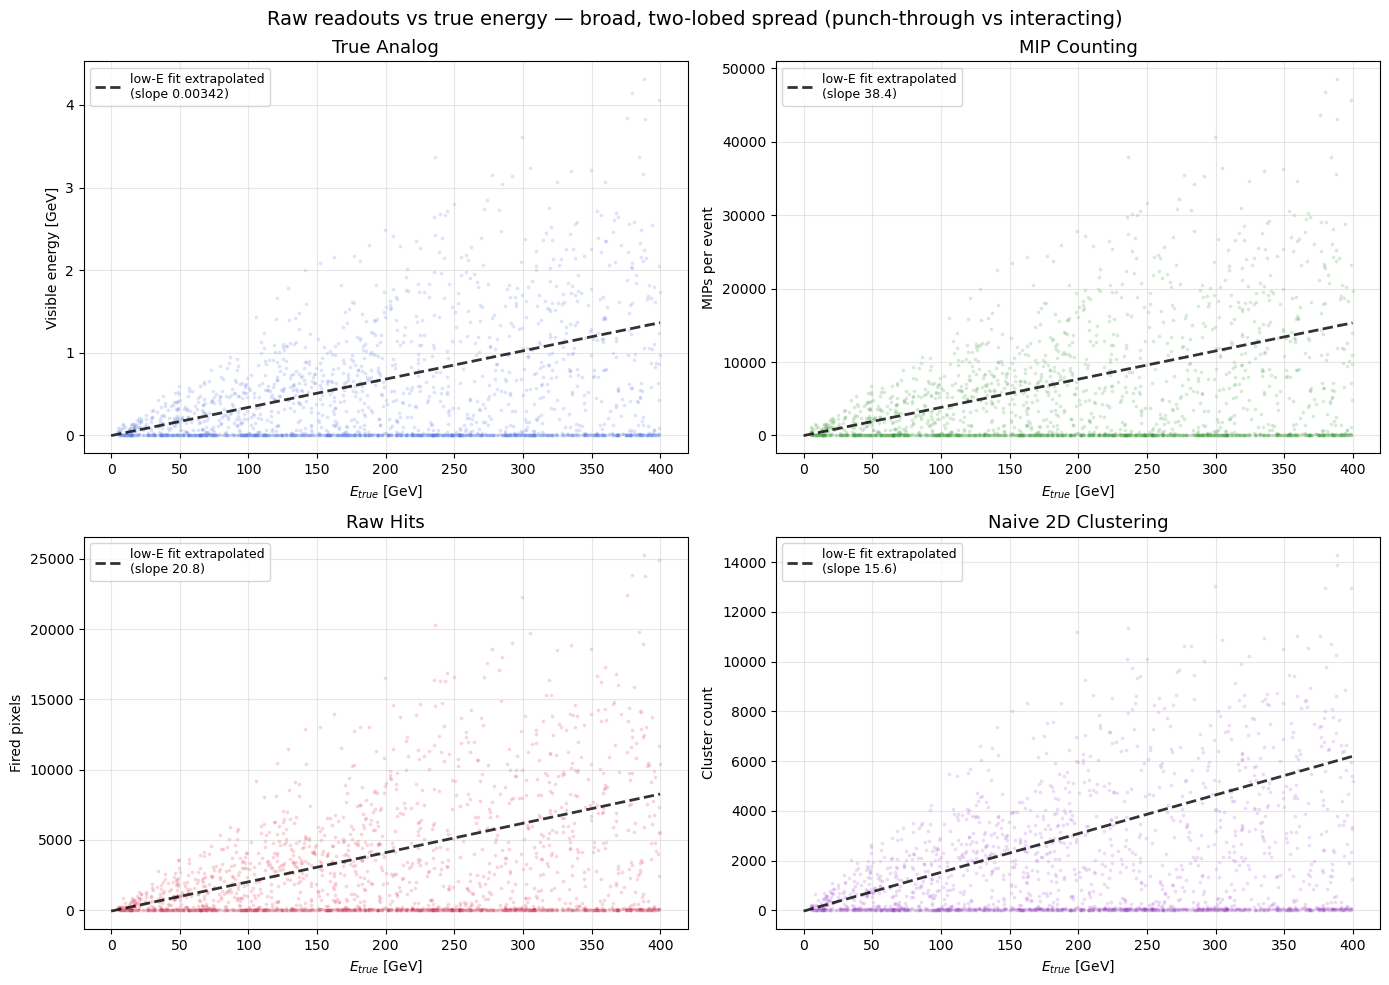

In [4]:
import matplotlib.pyplot as plt

panels = [("True Analog", all_visible, "royalblue", "Visible energy [GeV]"),
          ("MIP Counting", all_mip, "forestgreen", "MIPs per event"),
          ("Raw Hits", all_hits, "crimson", "Fired pixels"),
          ("Naive 2D Clustering", all_cluster, "darkorchid", "Cluster count")]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, y, col, ylab) in zip(axes.flat, panels):
    good = (all_truth > 0) & (y > 0)
    t, yy = all_truth[good], y[good].astype(float)
    ax.scatter(t, yy, s=3, alpha=0.12, color=col)
    lo = t < 50
    if lo.sum() > 10:
        m, c = np.polyfit(t[lo], yy[lo], 1)
        xl = np.array([0, t.max()])
        ax.plot(xl, m * xl + c, "k--", lw=2, alpha=0.8,
                label=f"low-E fit extrapolated\n(slope {m:.3g})")
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("$E_{true}$ [GeV]"); ax.set_ylabel(ylab)
    ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("Raw readouts vs true energy — broad, two-lobed spread (punch-through vs interacting)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Why a *quantile* model? The response is a distribution

At any fixed true energy a readout doesn't give one value — it gives a spread
(shower-to-shower fluctuations). Below is the distribution of one readout in a
narrow energy slice. For π⁺ this distribution is **especially non-Gaussian**:
expect it to be **broad and often two-lobed**, with a punch-through peak at low
values and a tail (or second bump) from interacting showers. Its width sets the
resolution, which is why the surrogate learns three *quantiles* (median ± 1σ)
rather than assuming a single Gaussian — and why that flexibility matters even
more for pions than for photons.

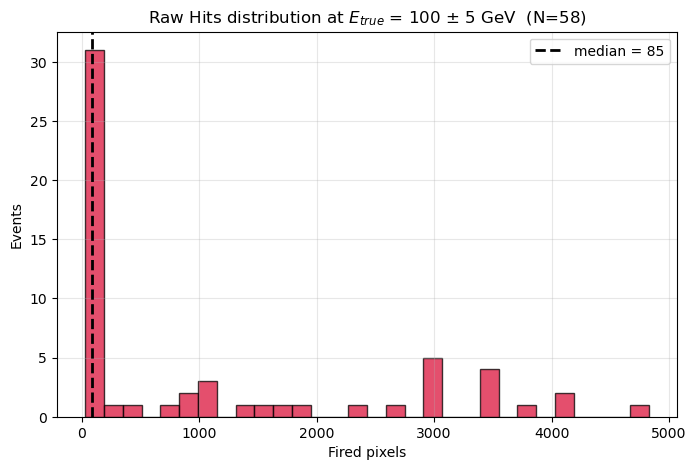

In [5]:
E0, dE = 100.0, 5.0
sl = np.abs(all_truth - E0) < dE
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_hits[sl], bins=30, color="crimson", alpha=0.75, edgecolor="black")
med = np.median(all_hits[sl])
ax.axvline(med, color="black", lw=2, ls="--", label=f"median = {med:.0f}")
ax.set_title(f"Raw Hits distribution at $E_{{true}}$ = {E0:.0f} $\\pm$ {dE:.0f} GeV  (N={sl.sum()})")
ax.set_xlabel("Fired pixels"); ax.set_ylabel("Events")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## 7. Longitudinal shower profile

How deep does the energy go, and how does that change with energy? Averaging the
per-layer energy in each 25 GeV bin gives the **longitudinal shower profile**.
For photons this is a smooth EM curve that peaks deeper as energy grows. **For
π⁺ the average is lower and flatter**: it blends nearly-flat punch-through tracks
(a thin MIP deposit across every layer) with the minority of interacting events
whose energy lands deep and at a random starting depth. Don't expect the clean
photon-style peak — the absence of a sharp shower maximum *is* the hadronic
signature. The red line still marks where the absorber switches from thin
(2.5 mm W) to thick (5.0 mm W).

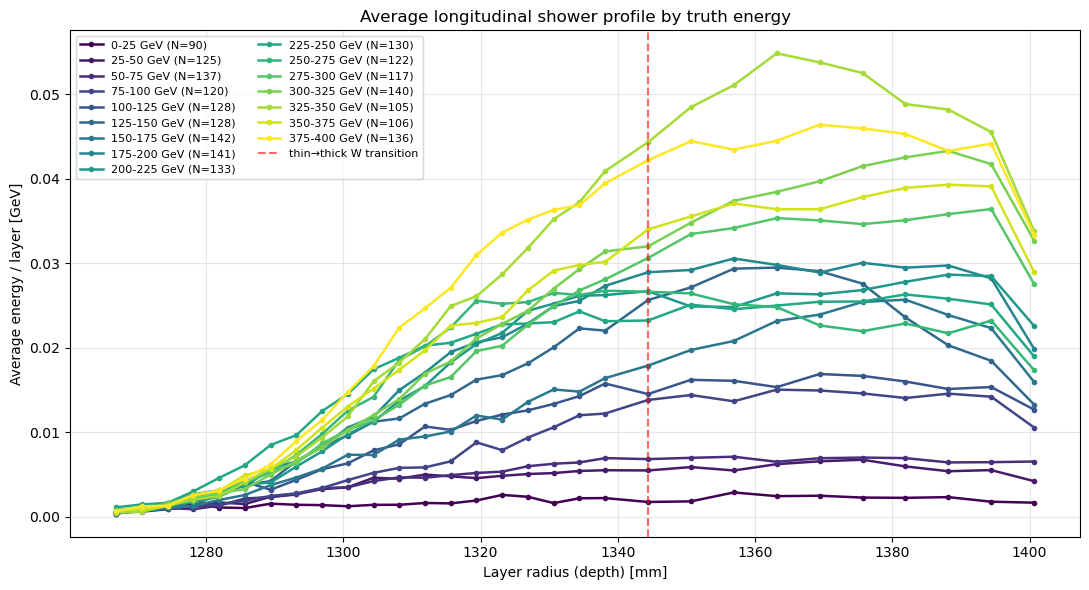

In [6]:
radii = RADII
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(PROFILE_BINS)))
for b, (lo, hi) in enumerate(PROFILE_BINS):
    if prof_cnt[b] == 0:
        continue
    avg = prof_sum[b] / prof_cnt[b]
    ax.plot(radii, avg, marker="o", ms=3, lw=1.8, color=cmap[b],
            label=f"{lo}-{hi} GeV (N={prof_cnt[b]})")
if len(radii) > 20:
    ax.axvline(radii[20], color="red", ls="--", alpha=0.6, label="thin→thick W transition")
ax.set_xlabel("Layer radius (depth) [mm]"); ax.set_ylabel("Average energy / layer [GeV]")
ax.set_title("Average longitudinal shower profile by truth energy")
ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Done. The π⁺ five-number summary (+ longitudinal profile) is saved to
`decal_extracted_data_piplus.npz`. Next:
[`03b_ml_training_and_eval_pions.ipynb`](03b_ml_training_and_eval_pions.ipynb)
trains a Deep Quantile Ensemble on each pion readout and runs the Neyman-inversion
reconstruction — then compare its resolution dashboard with the photon sibling to
read off the EM-vs-hadronic difference directly.